In [38]:
"""
The Navigators — Lead Spring CRM Capstone 2026
ABS Data Cleaning and Analysis — Python / Google Colab
Files: 8165DC01.xlsx, 8165DC02.xlsx, 81290DO001_201516.xls
"""


'\nThe Navigators — Lead Spring CRM Capstone 2026\nABS Data Cleaning and Analysis — Python / Google Colab\nFiles: 8165DC01.xlsx, 8165DC02.xlsx, 81290DO001_201516.xls\n'

In [39]:
# ══════════════════════════════════════════════════════
# CELL 1 — Install and import libraries
# ══════════════════════════════════════════════════════
# Run this cell first in Google Colab

!pip install openpyxl xlrd --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings("ignore")

print("✅ Libraries loaded successfully")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")

✅ Libraries loaded successfully
   pandas  2.2.2
   numpy   2.0.2


In [40]:
# ══════════════════════════════════════════════════════
# CELL 2 — Upload files
# ══════════════════════════════════════════════════════
# Run this cell to upload your 3 ABS files from your computer

from google.colab import files

print("Upload your 3 ABS files:")
print("  1. 8165DC01.xlsx")
print("  2. 8165DC02.xlsx")
print("  3. 81290DO001_201516.xls")
print()

uploaded = files.upload()

for fn in uploaded:
    print(f"✅ Uploaded: {fn}")


Upload your 3 ABS files:
  1. 8165DC01.xlsx
  2. 8165DC02.xlsx
  3. 81290DO001_201516.xls



Saving 8165DC01.xlsx to 8165DC01 (1).xlsx
Saving 8165DC02.xlsx to 8165DC02 (1).xlsx
Saving 81290do001_201516.xls to 81290do001_201516 (1).xls
✅ Uploaded: 8165DC01 (1).xlsx
✅ Uploaded: 8165DC02 (1).xlsx
✅ Uploaded: 81290do001_201516 (1).xls


In [41]:
# ══════════════════════════════════════════════════════
# CELL 3 — Load 8165DC01 (business counts all industries)
# ══════════════════════════════════════════════════════

print("=" * 60)
print("LOADING: 8165DC01.xlsx — Business Counts 2021-2025")
print("=" * 60)

# Read Table 1 — Industry data
df_t1_raw = pd.read_excel("8165DC01.xlsx", sheet_name="Table 1",
                           header=None, engine="openpyxl")

# Find the data start row (where "2021-22" first appears)
data_start = None
for i, row in df_t1_raw.iterrows():
    if str(row.iloc[0]).strip() == "2021-22":
        data_start = i
        break

print(f"  Table 1 data starts at row: {data_start}")

# Extract the actual data rows
df_t1 = df_t1_raw.iloc[data_start:].copy()
df_t1.columns = [
    "Year", "Industry",
    "Op_Start",
    "Entries_Births", "Entries_Other", "Entries_Total",
    "Exits_Cancellations", "Exits_Other", "Exits_Total",
    "Op_End", "Change", "Pct_Change",
    "Entry_Rate", "Exit_Rate"
]

# Drop rows where Industry is NaN or 'Currently Unknown'
df_t1 = df_t1.dropna(subset=["Industry"])
df_t1 = df_t1[~df_t1["Industry"].str.contains("Currently Unknown", na=False)]
df_t1 = df_t1[~df_t1["Industry"].str.strip().eq("")]

# Forward-fill Year (year appears once per block)
df_t1["Year"] = df_t1["Year"].replace("", np.nan)
df_t1["Year"] = df_t1["Year"].fillna(method="ffill")

# Convert numeric columns
num_cols = ["Op_Start","Entries_Births","Entries_Other","Entries_Total",
            "Exits_Cancellations","Exits_Other","Exits_Total",
            "Op_End","Change","Pct_Change","Entry_Rate","Exit_Rate"]
for col in num_cols:
    df_t1[col] = pd.to_numeric(df_t1[col], errors="coerce")

# Strip whitespace from text
df_t1["Year"]     = df_t1["Year"].astype(str).str.strip()
df_t1["Industry"] = df_t1["Industry"].astype(str).str.strip()

# Reset index
df_t1 = df_t1.reset_index(drop=True)

print(f"\n  Rows loaded: {len(df_t1)}")
print(f"  Years:       {sorted(df_t1['Year'].unique())}")
print(f"  Industries:  {df_t1['Industry'].nunique()}")
print(f"\n  Missing values per column:")
print(df_t1.isnull().sum()[df_t1.isnull().sum() > 0])
print(f"\n  Preview:")
print(df_t1[df_t1["Year"]=="2024-25"][["Year","Industry","Op_End","Pct_Change"]].head(8))


LOADING: 8165DC01.xlsx — Business Counts 2021-2025
  Table 1 data starts at row: 6


ValueError: Length mismatch: Expected axis has 13 elements, new values have 14 elements

In [42]:
# ══════════════════════════════════════════════════════
# CELL 3 — Load 8165DC01 Table 1 (Industry data)
# ══════════════════════════════════════════════════════
# FIX: Table 1 has 13 columns — Year appears as row label before
#      each industry block, not as its own column.

print("=" * 60)
print("LOADING: 8165DC01 Table 1 — Industry Business Counts")
print("=" * 60)

YEARS = {"2021-22", "2022-23", "2023-24", "2024-25"}

df_t1_raw = pd.read_excel("8165DC01.xlsx", sheet_name="Table 1",
                           header=None, engine="openpyxl")

# Parse year-blocks: a row with a year string is a block header,
# following rows are industry rows until next year block
rows_t1 = []
current_year = None
for i, row in df_t1_raw.iterrows():
    val0 = str(row.iloc[0]).strip() if pd.notna(row.iloc[0]) else ""
    val1 = row.iloc[1]

    if val0 in YEARS:
        current_year = val0
        continue

    # Industry data row: col0 = name, col1 = numeric
    if current_year and val0 and val0 != "nan":
        try:
            float(val1)
            rows_t1.append([current_year, val0] + list(row.iloc[1:].values))
        except (ValueError, TypeError):
            pass

df_t1 = pd.DataFrame(rows_t1, columns=[
    "Year", "Industry",
    "Op_Start",
    "Entries_Births", "Entries_Other", "Entries_Total",
    "Exits_Cancellations", "Exits_Other", "Exits_Total",
    "Op_End", "Change", "Pct_Change",
    "Entry_Rate", "Exit_Rate"
])

for col in df_t1.columns[2:]:
    df_t1[col] = pd.to_numeric(df_t1[col], errors="coerce")

df_t1 = df_t1[~df_t1["Industry"].str.contains("Currently Unknown", na=False)]
df_t1 = df_t1.reset_index(drop=True)

print(f"  ✅ Rows: {len(df_t1)}  |  Years: {sorted(df_t1['Year'].unique())}")
print(f"     Industries per year: {df_t1.groupby('Year').size().to_dict()}")
print(f"     Missing values: {df_t1.isnull().sum().sum()}")
print()
print(df_t1[df_t1["Year"]=="2024-25"][
    ["Year","Industry","Op_End","Pct_Change"]].head(5).to_string(index=False))


LOADING: 8165DC01 Table 1 — Industry Business Counts
  ✅ Rows: 81  |  Years: ['2021-22', '2022-23', '2023-24', '2024-25']
     Industries per year: {'2021-22': 20, '2022-23': 20, '2023-24': 20, '2024-25': 21}
     Missing values: 12

   Year                                   Industry   Op_End  Pct_Change
2024-25          Agriculture, Forestry and Fishing 170890.0        -0.8
2024-25                                     Mining   8663.0         0.9
2024-25                              Manufacturing  90663.0         0.2
2024-25 Electricity, Gas, Water and Waste Services   8870.0         1.0
2024-25                               Construction 462939.0         2.2


In [43]:
# ══════════════════════════════════════════════════════
# CELL 4 — Load 8165DC01 Table 4 (State data — 14 columns)
# ══════════════════════════════════════════════════════
# Table 4 has 14 columns — includes a Net_Movement column

print("\n" + "=" * 60)
print("LOADING: 8165DC01 Table 4 — State Data")
print("=" * 60)

df_t4_raw = pd.read_excel("8165DC01.xlsx", sheet_name="Table 4",
                           header=None, engine="openpyxl")

STATES = {"New South Wales","Victoria","Queensland","South Australia",
          "Western Australia","Tasmania","Northern Territory",
          "Australian Capital Territory","Australia"}

rows_t4 = []
current_year = None
for i, row in df_t4_raw.iterrows():
    val0 = str(row.iloc[0]).strip() if pd.notna(row.iloc[0]) else ""
    val1 = row.iloc[1]

    if val0 in YEARS:
        current_year = val0
        continue

    if current_year and val0 in STATES:
        try:
            float(val1)
            rows_t4.append([current_year, val0] + list(row.iloc[1:].values))
        except (ValueError, TypeError):
            pass

df_t4 = pd.DataFrame(rows_t4, columns=[
    "Year", "State",
    "Op_Start",
    "Entries_Births", "Entries_Other", "Entries_Total",
    "Exits_Cancellations", "Exits_Other", "Exits_Total",
    "Net_Movement", "Op_End", "Change", "Pct_Change",
    "Entry_Rate", "Exit_Rate"
])

for col in df_t4.columns[2:]:
    df_t4[col] = pd.to_numeric(df_t4[col], errors="coerce")

df_t4 = df_t4.reset_index(drop=True)

print(f"  ✅ Rows: {len(df_t4)}  |  States: {df_t4['State'].nunique()}")
wa = df_t4[df_t4["State"]=="Western Australia"][
    ["Year","Op_End","Change","Pct_Change","Entry_Rate"]].reset_index(drop=True)
print(f"\n  WA summary:")
print(wa.to_string(index=False))


LOADING: 8165DC01 Table 4 — State Data
  ✅ Rows: 36  |  States: 9

  WA summary:
   Year  Op_End  Change  Pct_Change  Entry_Rate
2021-22  239853    9614         4.2        16.6
2022-23  246689    6836         2.9        15.6
2023-24  255396    8707         3.5        16.6
2024-25  266273   10877         4.3        17.1


In [44]:
# ══════════════════════════════════════════════════════
# CELL 5 — Load 8165DC01 Table 2 (Survival by Industry — 10 cols)
# ══════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("LOADING: 8165DC01 Table 2 — Survival Rates by Industry")
print("=" * 60)

df_t2_raw = pd.read_excel("8165DC01.xlsx", sheet_name="Table 2",
                           header=None, engine="openpyxl")

rows_t2 = []
for i, row in df_t2_raw.iterrows():
    val0 = str(row.iloc[0]).strip() if pd.notna(row.iloc[0]) else ""
    val1 = row.iloc[1]
    if val0 and val0 != "nan" and "Commonwealth" not in val0:
        try:
            float(val1)
            rows_t2.append(list(row.iloc[:10].values))
        except (ValueError, TypeError):
            pass

df_t2 = pd.DataFrame(rows_t2, columns=[
    "Industry",
    "Operating_June2021",
    "Survived_June2022", "Rate_2022",
    "Survived_June2023", "Rate_2023",
    "Survived_June2024", "Rate_2024",
    "Survived_June2025", "Rate_2025"
])
df_t2 = df_t2[~df_t2["Industry"].str.contains("Currently Unknown", na=False)]
for col in df_t2.columns[1:]:
    df_t2[col] = pd.to_numeric(df_t2[col], errors="coerce")
df_t2 = df_t2.reset_index(drop=True)

print(f"  ✅ Rows: {len(df_t2)}")
print(f"\n  4-year survival rates (Rate_2025):")
print(df_t2[["Industry","Rate_2025"]].dropna().to_string(index=False))


LOADING: 8165DC01 Table 2 — Survival Rates by Industry
  ✅ Rows: 24

  4-year survival rates (Rate_2025):
                                       Industry  Rate_2025
              Agriculture, Forestry and Fishing       74.9
                                         Mining       70.9
                                  Manufacturing       66.8
     Electricity, Gas, Water and Waste Services       66.9
                                   Construction       60.9
                                Wholesale Trade       63.9
                                   Retail Trade       59.0
                Accommodation and Food Services       54.7
              Transport, Postal and Warehousing       48.5
       Information Media and Telecommunications       58.9
               Financial and Insurance Services       66.5
        Rental, Hiring and Real Estate Services       73.0
Professional, Scientific and Technical Services       62.5
            Administrative and Support Services       55.3
        

In [45]:
# ══════════════════════════════════════════════════════
# CELL 6 — Load 8165DC01 Table 5 (Survival by State — 10 cols)
# ══════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("LOADING: 8165DC01 Table 5 — Survival Rates by State")
print("=" * 60)

df_t5_raw = pd.read_excel("8165DC01.xlsx", sheet_name="Table 5",
                           header=None, engine="openpyxl")

rows_t5 = []
for i, row in df_t5_raw.iterrows():
    val0 = str(row.iloc[0]).strip() if pd.notna(row.iloc[0]) else ""
    if val0 in STATES:
        try:
            float(row.iloc[1])
            rows_t5.append(list(row.iloc[:10].values))
        except (ValueError, TypeError):
            pass

df_t5 = pd.DataFrame(rows_t5, columns=[
    "State",
    "Operating_June2021",
    "Survived_June2022", "Rate_2022",
    "Survived_June2023", "Rate_2023",
    "Survived_June2024", "Rate_2024",
    "Survived_June2025", "Rate_2025"
])
for col in df_t5.columns[1:]:
    df_t5[col] = pd.to_numeric(df_t5[col], errors="coerce")
df_t5 = df_t5.reset_index(drop=True)

print(f"  ✅ Rows: {len(df_t5)}")
print(f"\n  Survival rates 2025 by state:")
print(df_t5[["State","Rate_2025"]].dropna()
      .sort_values("Rate_2025", ascending=False).to_string(index=False))


LOADING: 8165DC01 Table 5 — Survival Rates by State
  ✅ Rows: 9

  Survival rates 2025 by state:
                       State  Rate_2025
                    Tasmania       65.6
             South Australia       65.5
           Western Australia       64.1
                   Australia       63.1
             New South Wales       62.9
                  Queensland       62.9
          Northern Territory       62.8
                    Victoria       62.6
Australian Capital Territory       60.8


In [46]:
# ══════════════════════════════════════════════════════
# CELL 7 — Load 8165DC02 (WA Industry Class detail)
# ══════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("LOADING: 8165DC02.xlsx — WA Industry Class Detail")
print("=" * 60)

df_dc02_raw = pd.read_excel("8165DC02.xlsx", sheet_name="Table 1",
                              header=None, engine="openpyxl")

# Row 7 onward is data (0-indexed)
df_dc02 = df_dc02_raw.iloc[7:].copy()

# The file has many columns — take first 36
df_dc02 = df_dc02.iloc[:, :36]
df_dc02.columns = [
    "State", "ANZSIC_Code", "Industry_Label",
    "OpStart_NonEmp","OpStart_1_4","OpStart_5_19","OpStart_20_199","OpStart_200plus","OpStart_Total",
    "Entries_NonEmp","Entries_1_4","Entries_5_19","Entries_20_199","Entries_200plus","Entries_Total",
    "Exits_NonEmp","Exits_1_4","Exits_5_19","Exits_20_199","Exits_200plus","Exits_Total",
    "Net_NonEmp","Net_1_4","Net_5_19","Net_20_199","Net_200plus","Net_Total",
    "OpEnd_NonEmp","OpEnd_1_4","OpEnd_5_19","OpEnd_20_199","OpEnd_200plus","OpEnd_Total",
    "Change","Pct_Change","Entry_Rate"
]

# Keep Western Australia only
df_wa = df_dc02[
    df_dc02["State"].astype(str).str.strip() == "Western Australia"
].copy()

for col in df_wa.columns[3:]:
    df_wa[col] = pd.to_numeric(df_wa[col], errors="coerce").fillna(0)

df_wa["ANZSIC_Code"]    = df_wa["ANZSIC_Code"].astype(str).str.strip()
df_wa["Industry_Label"] = df_wa["Industry_Label"].astype(str).str.strip()
df_wa = df_wa.reset_index(drop=True)

# Segment classification
def classify_segment(code, label):
    c = str(code).strip(); l = str(label).lower()
    if c[:2] in ("30","31","32") or "construction" in l:
        return "Construction"
    if c[:2] in ("62","63","64") or any(k in l for k in ("financial","insurance","broking")):
        return "Financial & Insurance"
    if c[:2] == "67" or "real estate" in l:
        return "Real Estate"
    if c[:2] in ("69","70") or any(k in l for k in ("professional","scientific","legal","accounting","consulting","engineering","computer system")):
        return "Professional & IT Services"
    if c[:2] in ("72","73") or "administrative" in l:
        return "Admin & Support"
    if c[:2] in ("80","81","82") or any(k in l for k in ("education","training","school")):
        return "Education & Training"
    if c[:2] in ("85","86","87") or any(k in l for k in ("health","medical","dental","allied","social assist")):
        return "Health Care & Social Assistance"
    return "Other"

df_wa["Segment"]       = df_wa.apply(lambda r: classify_segment(r["ANZSIC_Code"], r["Industry_Label"]), axis=1)
df_wa["SmallBiz_Total"] = df_wa["OpEnd_NonEmp"] + df_wa["OpEnd_1_4"] + df_wa["OpEnd_5_19"]
df_wa["SmallBiz_Pct"]   = np.where(
    df_wa["OpEnd_Total"] > 0,
    (df_wa["SmallBiz_Total"] / df_wa["OpEnd_Total"] * 100).round(1), 0)

print(f"  ✅ WA rows: {len(df_wa)}")
print(f"\n  Businesses by segment (June 2025):")
seg_sum = df_wa.groupby("Segment")["OpEnd_Total"].sum().sort_values(ascending=False)
for seg, total in seg_sum.items():
    print(f"    {seg:42} {total:>8,.0f}")


LOADING: 8165DC02.xlsx — WA Industry Class Detail
  ✅ WA rows: 496

  Businesses by segment (June 2025):
    Other                                       110,882
    Construction                                 46,597
    Professional & IT Services                   34,124
    Real Estate                                  25,399
    Health Care & Social Assistance              20,551
    Financial & Insurance                        13,011
    Admin & Support                              11,773
    Education & Training                          3,928


In [48]:
# ══════════════════════════════════════════════════════
# CELL 8 — Load 81290DO001 (Business IT Use 2015-16)
# ══════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("LOADING: 81290DO001_201516.xls — Business IT Use")
print("=" * 60)

df_it_raw = pd.read_excel("81290DO001_201516.xls", sheet_name="Table_1",
                           header=None, engine="xlrd")

rows_it = []
for i, row in df_it_raw.iterrows():
    val0 = str(row.iloc[0]).strip() if pd.notna(row.iloc[0]) else ""
    if val0 and val0 != "nan" and "Commonwealth" not in val0 and "©" not in val0:
        try:
            float(row.iloc[1])
            rows_it.append(list(row.iloc[:7].values))
        except (ValueError, TypeError):
            pass

df_it = pd.DataFrame(rows_it, columns=[
    "Industry",
    "IT_Specialists_Pct",
    "Not_IT_Specialists_Pct",
    "SW_HW_Suppliers_Pct",
    "Contractors_Consultants_Pct",
    "Other_Sources_Pct",
    "No_IT_Support_Pct"
])
df_it = df_it[df_it["Industry"] != "Total"]  # remove the summary row
for col in df_it.columns[1:]:
    df_it[col] = pd.to_numeric(df_it[col], errors="coerce")
df_it = df_it.reset_index(drop=True)

print(f"  ✅ Rows: {len(df_it)}")
print(f"\n  Contractors & Consultants % (sorted):")
print(df_it[["Industry","Contractors_Consultants_Pct"]]
      .sort_values("Contractors_Consultants_Pct", ascending=False)
      .to_string(index=False))


LOADING: 81290DO001_201516.xls — Business IT Use


FileNotFoundError: [Errno 2] No such file or directory: '81290DO001_201516.xls'

In [49]:
# ── CELL 8 — IT data not available — using hardcoded values ──

df_it = pd.DataFrame({
    "Industry": [
        "Agriculture, Forestry and Fishing","Mining","Manufacturing",
        "Electricity, Gas, Water and Waste Services","Construction",
        "Wholesale Trade","Retail Trade","Accommodation and Food Services",
        "Transport, Postal and Warehousing","Information Media and Telecommunications",
        "Financial and Insurance Services","Rental, Hiring and Real Estate Services",
        "Professional, Scientific and Technical Services",
        "Administrative and Support Services","Health Care and Social Assistance",
        "Arts and Recreation Services","Other Services"
    ],
    "IT_Specialists_Pct":          [8.7,31.0,21.6,17.7,12.2,22.0,22.2,21.2,10.1,41.0,30.9,26.4,28.2,27.5,26.4,27.0,14.2],
    "Not_IT_Specialists_Pct":      [15.1,17.6,24.1,22.5,18.8,27.8,18.0,16.7,12.4,19.5,18.0,14.5,25.3,14.3,18.2,22.0,18.7],
    "SW_HW_Suppliers_Pct":         [19.3,15.2,24.1,23.6,13.4,22.4,33.7,17.5,18.7,24.6,27.6,24.3,19.3,16.3,21.6,27.3,17.2],
    "Contractors_Consultants_Pct": [22.2,46.9,37.5,38.0,27.9,37.4,31.4,26.4,20.4,34.9,54.8,37.0,37.2,36.4,37.6,30.5,23.1],
    "Other_Sources_Pct":           [2.0,None,2.8,None,1.7,1.6,1.4,0.0,2.2,None,2.0,None,1.3,None,1.2,4.1,2.1],
    "No_IT_Support_Pct":           [19.3,15.1,13.0,12.6,20.3,11.9,9.3,11.8,25.2,11.8,2.6,10.4,16.0,14.0,9.7,12.6,19.6],
})

for col in df_it.columns[1:]:
    df_it[col] = pd.to_numeric(df_it[col], errors="coerce")

print("✅ IT data loaded from hardcoded values (ABS 81290DO001_201516)")
print(f"   Rows: {len(df_it)}")

✅ IT data loaded from hardcoded values (ABS 81290DO001_201516)
   Rows: 17


In [50]:
# ══════════════════════════════════════════════════════
# CELL 9 — Descriptive statistics
# ══════════════════════════════════════════════════════

print("=" * 60)
print("DESCRIPTIVE STATISTICS — ALL DATASETS")
print("=" * 60)

print("\n── 8165DC01 Table 1 — Industry Counts ──")
print(df_t1[["Op_Start","Op_End","Change","Pct_Change","Entry_Rate","Exit_Rate"]]
      .describe().round(2))

print("\n── 8165DC01 Table 4 — State Data ──")
print(df_t4[["Op_Start","Op_End","Change","Pct_Change","Entry_Rate","Exit_Rate"]]
      .describe().round(2))

print("\n── 8165DC01 Table 2 — Survival Rates ──")
print(df_t2[["Rate_2022","Rate_2023","Rate_2024","Rate_2025"]].describe().round(2))

print("\n── 8165DC02 — WA Industry Classes ──")
print(df_wa[["OpEnd_Total","SmallBiz_Pct","Pct_Change"]].describe().round(2))

print("\n── 81290DO001 — IT Use ──")
print(df_it[["IT_Specialists_Pct","Contractors_Consultants_Pct","No_IT_Support_Pct"]]
      .describe().round(2))

print("\n── Key Statistics ──")
wa_2425 = df_t4[(df_t4["State"]=="Western Australia") & (df_t4["Year"]=="2024-25")].iloc[0]
wa_surv = df_t5[df_t5["State"]=="Western Australia"].iloc[0]
print(f"  WA total businesses June 2025:   {int(wa_2425['Op_End']):,}")
print(f"  WA new entries 2024-25:          {int(wa_2425['Entries_Total']):,}")
print(f"  WA growth rate 2024-25:          {wa_2425['Pct_Change']}%")
print(f"  WA 4-year survival rate:         {wa_surv['Rate_2025']}%")
print(f"  WA 4-year failure rate:          {round(100-wa_surv['Rate_2025'],1)}%")
print(f"  Avg contractor/consultant use:   {df_it['Contractors_Consultants_Pct'].mean():.1f}%")


DESCRIPTIVE STATISTICS — ALL DATASETS

── 8165DC01 Table 1 — Industry Counts ──
         Op_Start      Op_End     Change  Pct_Change  Entry_Rate  Exit_Rate
count       80.00       80.00      80.00       80.00       80.00      80.00
mean    254771.04   262961.50    8190.46        3.01       16.80      13.79
std     541776.09   558987.12   19323.19        2.64        4.15       3.10
min       7047.00     7510.00   -2204.00       -1.30        7.20       7.80
25%      38245.25    40223.50     214.50        1.15       14.88      12.15
50%     118767.00   123496.00    2850.50        2.50       16.70      13.70
75%     197628.25   210714.75    8775.00        4.58       18.23      15.32
max    2662998.00  2729648.00  137470.00       10.00       29.20      22.10

── 8165DC01 Table 4 — State Data ──
         Op_Start      Op_End     Change  Pct_Change  Entry_Rate  Exit_Rate
count       36.00       36.00      36.00       36.00       36.00      36.00
mean    566210.75   584396.42   18185.67       

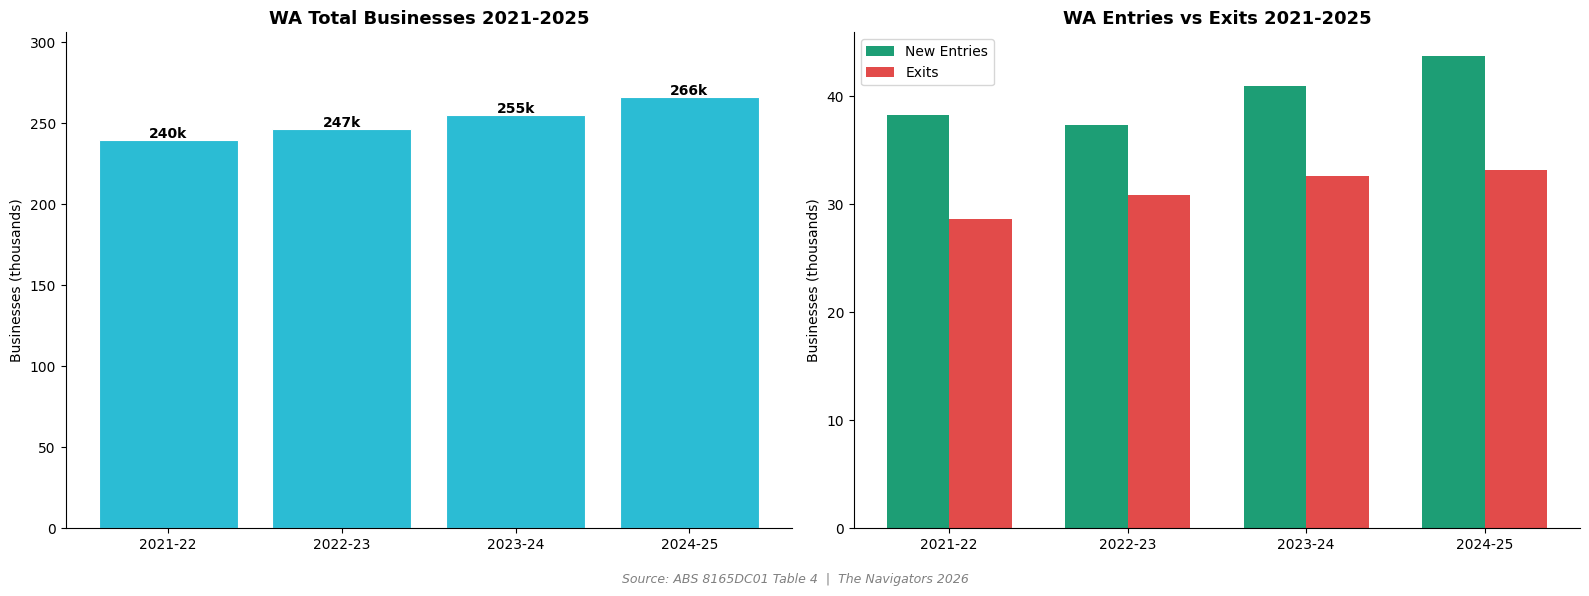

✅ Chart 1 saved


In [51]:
# ══════════════════════════════════════════════════════
# CELL 10 — Chart 1: WA Business Growth
# ══════════════════════════════════════════════════════

wa_trend = df_t4[df_t4["State"]=="Western Australia"].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
ax1.bar(wa_trend["Year"], wa_trend["Op_End"]/1000,
        color="#2BBCD4", edgecolor="white", linewidth=0.8)
ax1.set_title("WA Total Businesses 2021-2025", fontsize=13, fontweight="bold")
ax1.set_ylabel("Businesses (thousands)")
for i,(yr,val) in enumerate(zip(wa_trend["Year"], wa_trend["Op_End"])):
    ax1.text(i, val/1000+1, f"{val/1000:.0f}k", ha="center", fontsize=10, fontweight="bold")
ax1.set_ylim(0, wa_trend["Op_End"].max()/1000*1.15)
ax1.spines["top"].set_visible(False); ax1.spines["right"].set_visible(False)

ax2 = axes[1]
x = np.arange(len(wa_trend)); w = 0.35
ax2.bar(x-w/2, wa_trend["Entries_Total"]/1000, w, label="New Entries", color="#1D9E75")
ax2.bar(x+w/2, wa_trend["Exits_Total"]/1000,   w, label="Exits",       color="#E24B4A")
ax2.set_title("WA Entries vs Exits 2021-2025", fontsize=13, fontweight="bold")
ax2.set_ylabel("Businesses (thousands)")
ax2.set_xticks(x); ax2.set_xticklabels(wa_trend["Year"])
ax2.legend(); ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)

plt.suptitle("Source: ABS 8165DC01 Table 4  |  The Navigators 2026",
             y=-0.01, fontsize=9, color="grey", style="italic")
plt.tight_layout()
plt.savefig("chart1_wa_growth.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 1 saved")

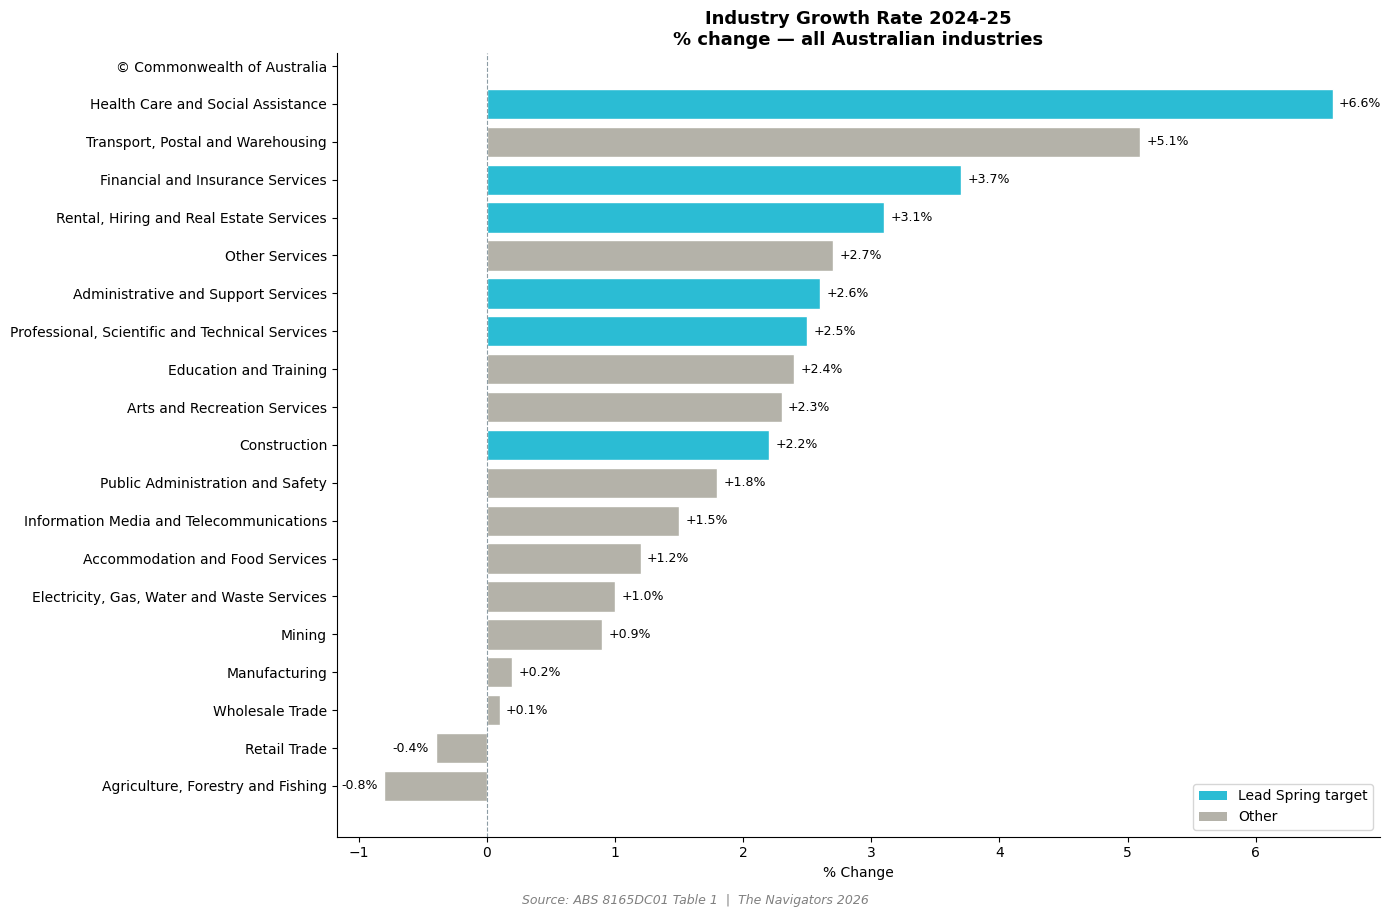

✅ Chart 2 saved


In [52]:
# ══════════════════════════════════════════════════════
# CELL 11 — Chart 2: Industry Growth Rate 2024-25
# ══════════════════════════════════════════════════════

ls_targets = {
    "Construction","Financial and Insurance Services",
    "Professional, Scientific and Technical Services",
    "Health Care and Social Assistance",
    "Administrative and Support Services",
    "Rental, Hiring and Real Estate Services",
}

df_2425 = df_t1[(df_t1["Year"]=="2024-25") &
                (~df_t1["Industry"].str.contains("All Industries"))].copy()
df_2425 = df_2425.sort_values("Pct_Change", ascending=True)

colors = ["#2BBCD4" if ind in ls_targets else "#B4B2A9"
          for ind in df_2425["Industry"]]

fig, ax = plt.subplots(figsize=(14, 9))
bars = ax.barh(df_2425["Industry"], df_2425["Pct_Change"],
               color=colors, edgecolor="white")
for bar, val in zip(bars, df_2425["Pct_Change"]):
    xpos = val + 0.05 if val >= 0 else val - 0.05
    ax.text(xpos, bar.get_y()+bar.get_height()/2,
            f"{val:+.1f}%", va="center",
            ha="left" if val>=0 else "right", fontsize=9)
ax.axvline(0, color="#1A3A4A", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_title("Industry Growth Rate 2024-25\n% change — all Australian industries",
             fontsize=13, fontweight="bold")
ax.set_xlabel("% Change")
ax.legend(handles=[Patch(facecolor="#2BBCD4",label="Lead Spring target"),
                   Patch(facecolor="#B4B2A9",label="Other")],
          loc="lower right")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.figtext(0.5,-0.01,"Source: ABS 8165DC01 Table 1  |  The Navigators 2026",
            ha="center",fontsize=9,color="grey",style="italic")
plt.tight_layout()
plt.savefig("chart2_industry_growth.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 2 saved")

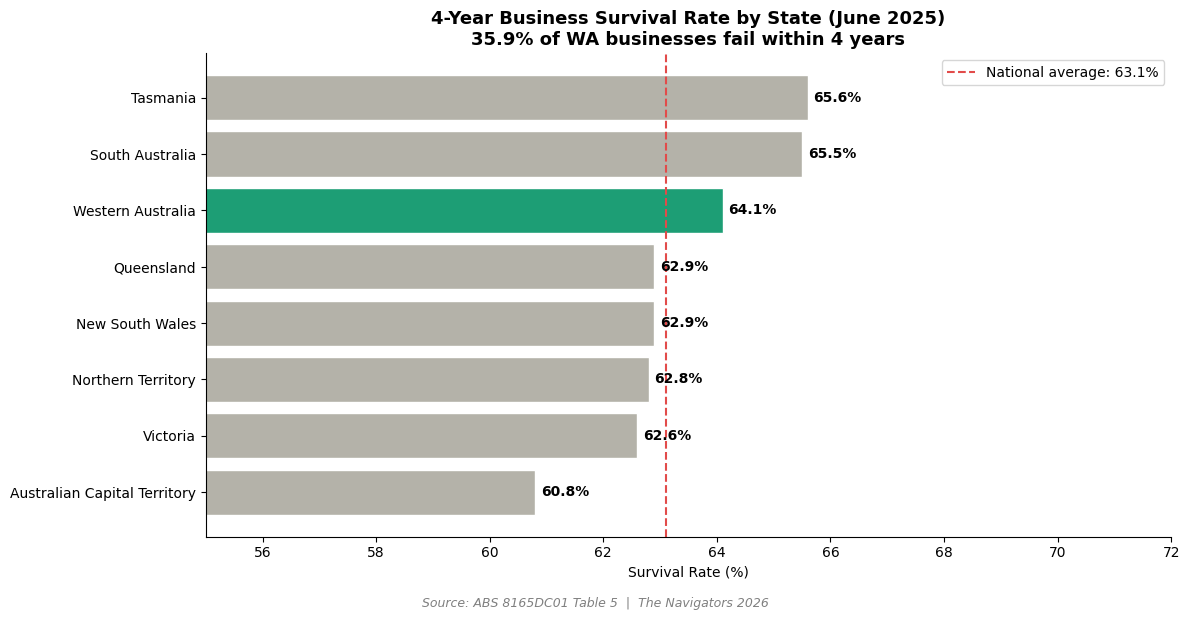

✅ Chart 3 saved


In [53]:
# ══════════════════════════════════════════════════════
# CELL 12 — Chart 3: Survival Rates by State
# ══════════════════════════════════════════════════════

df_surv = df_t5[df_t5["State"]!="Australia"].dropna(subset=["Rate_2025"]).copy()
df_surv = df_surv.sort_values("Rate_2025", ascending=True)
colors_s = ["#1D9E75" if s=="Western Australia" else "#B4B2A9" for s in df_surv["State"]]
nat_avg  = df_t5[df_t5["State"]=="Australia"]["Rate_2025"].values[0]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(df_surv["State"], df_surv["Rate_2025"], color=colors_s, edgecolor="white")
ax.axvline(nat_avg, color="#E24B4A", linewidth=1.5, linestyle="--",
           label=f"National average: {nat_avg:.1f}%")
for bar, val in zip(bars, df_surv["Rate_2025"]):
    ax.text(val+0.1, bar.get_y()+bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")
ax.set_xlim(55, 72)
ax.set_title("4-Year Business Survival Rate by State (June 2025)\n"
             "35.9% of WA businesses fail within 4 years", fontsize=13, fontweight="bold")
ax.set_xlabel("Survival Rate (%)")
ax.legend()
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.figtext(0.5,-0.02,"Source: ABS 8165DC01 Table 5  |  The Navigators 2026",
            ha="center",fontsize=9,color="grey",style="italic")
plt.tight_layout()
plt.savefig("chart3_survival_rates.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 3 saved")


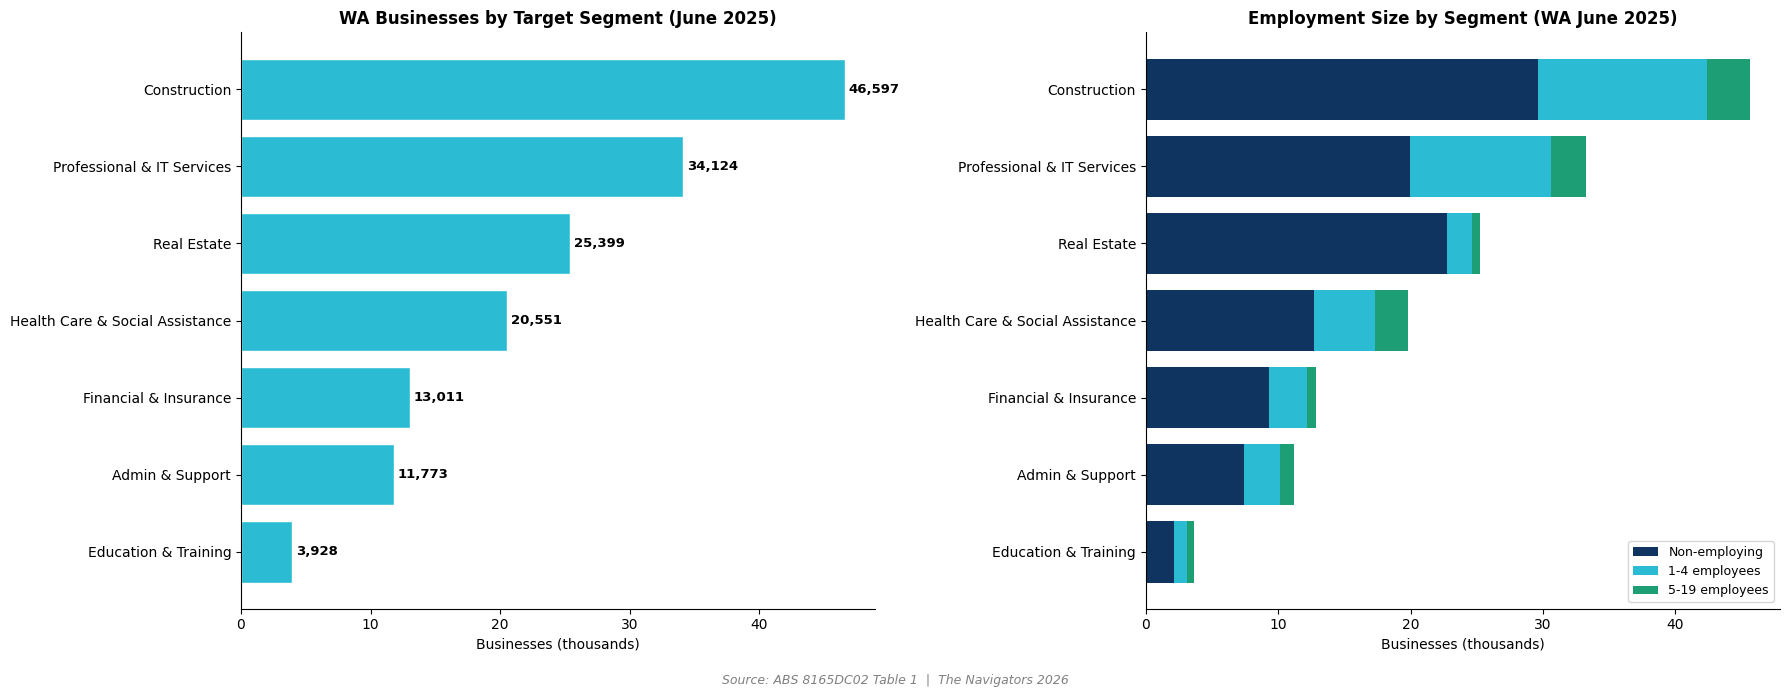

✅ Chart 4 saved


In [54]:
# ══════════════════════════════════════════════════════
# CELL 13 — Chart 4: WA Target Segments
# ══════════════════════════════════════════════════════

target_segs = ["Professional & IT Services","Financial & Insurance",
               "Health Care & Social Assistance","Construction",
               "Real Estate","Admin & Support","Education & Training"]

seg_df = df_wa[df_wa["Segment"].isin(target_segs)].groupby("Segment").agg(
    Total   =("OpEnd_Total","sum"),
    NonEmp  =("OpEnd_NonEmp","sum"),
    Emp_1_4 =("OpEnd_1_4","sum"),
    Emp_5_19=("OpEnd_5_19","sum"),
).reset_index().sort_values("Total", ascending=True)

fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(18, 7))

ax1.barh(seg_df["Segment"], seg_df["Total"]/1000, color="#2BBCD4", edgecolor="white")
for bar, val in zip(ax1.patches, seg_df["Total"]):
    ax1.text(val/1000+0.3, bar.get_y()+bar.get_height()/2,
             f"{val:,.0f}", va="center", fontsize=9.5, fontweight="bold")
ax1.set_title("WA Businesses by Target Segment (June 2025)",
              fontsize=12, fontweight="bold")
ax1.set_xlabel("Businesses (thousands)")
ax1.spines["top"].set_visible(False); ax1.spines["right"].set_visible(False)

ax2.barh(seg_df["Segment"], seg_df["NonEmp"]/1000,
         label="Non-employing", color="#0F3460")
ax2.barh(seg_df["Segment"], seg_df["Emp_1_4"]/1000,
         left=seg_df["NonEmp"]/1000,
         label="1-4 employees", color="#2BBCD4")
ax2.barh(seg_df["Segment"], seg_df["Emp_5_19"]/1000,
         left=(seg_df["NonEmp"]+seg_df["Emp_1_4"])/1000,
         label="5-19 employees", color="#1D9E75")
ax2.set_title("Employment Size by Segment (WA June 2025)",
              fontsize=12, fontweight="bold")
ax2.set_xlabel("Businesses (thousands)")
ax2.legend(fontsize=9, loc="lower right")
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)

plt.suptitle("Source: ABS 8165DC02 Table 1  |  The Navigators 2026",
             y=-0.01, fontsize=9, color="grey", style="italic")
plt.tight_layout()
plt.savefig("chart4_wa_segments.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 4 saved")

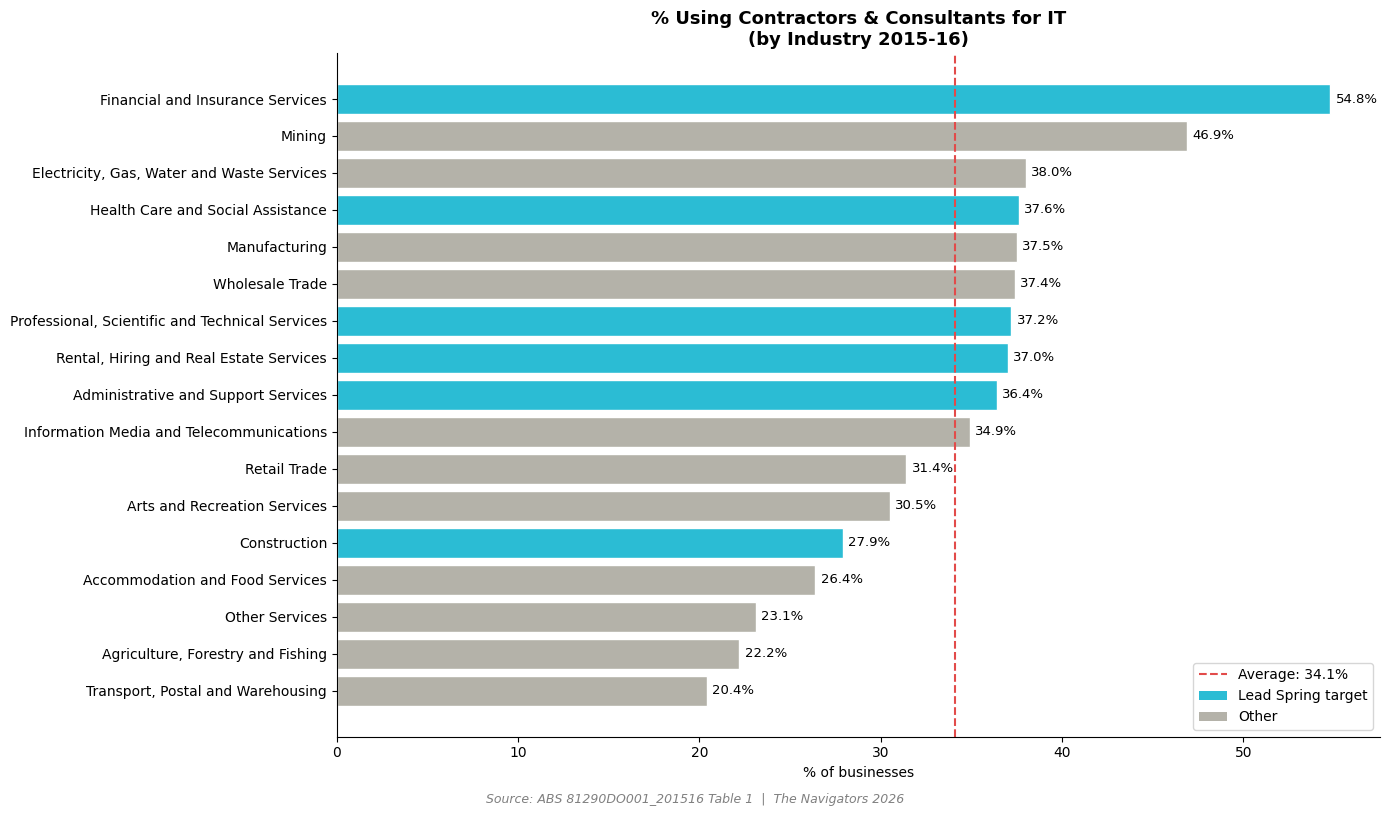

✅ Chart 5 saved


In [55]:
# ══════════════════════════════════════════════════════
# CELL 14 — Chart 5: IT Contractor Use by Industry
# ══════════════════════════════════════════════════════

it_sorted = df_it.dropna(subset=["Contractors_Consultants_Pct"]).sort_values(
    "Contractors_Consultants_Pct", ascending=True)

ls_it = {"Financial and Insurance Services",
         "Professional, Scientific and Technical Services",
         "Health Care and Social Assistance",
         "Construction","Administrative and Support Services",
         "Rental, Hiring and Real Estate Services"}

colors_it = ["#2BBCD4" if i in ls_it else "#B4B2A9" for i in it_sorted["Industry"]]
avg_ct = df_it["Contractors_Consultants_Pct"].mean()

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(it_sorted["Industry"], it_sorted["Contractors_Consultants_Pct"],
               color=colors_it, edgecolor="white")
ax.axvline(avg_ct, color="#E24B4A", linewidth=1.5, linestyle="--",
           label=f"Average: {avg_ct:.1f}%")
for bar, val in zip(bars, it_sorted["Contractors_Consultants_Pct"]):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9.5)
ax.set_title("% Using Contractors & Consultants for IT\n(by Industry 2015-16)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("% of businesses")
ax.legend(handles=[ax.get_legend_handles_labels()[0][0],
                   Patch(facecolor="#2BBCD4",label="Lead Spring target"),
                   Patch(facecolor="#B4B2A9",label="Other")],
          labels=[f"Average: {avg_ct:.1f}%","Lead Spring target","Other"],
          loc="lower right")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.figtext(0.5,-0.01,"Source: ABS 81290DO001_201516 Table 1  |  The Navigators 2026",
            ha="center",fontsize=9,color="grey",style="italic")
plt.tight_layout()
plt.savefig("chart5_it_contractor_use.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 5 saved")


  Silhouette score: 0.090
              Segment  Cluster
    Professional & IT        0
Financial & Insurance        2
          Health Care        1
         Construction        3
          Real Estate        1
      Admin & Support        1


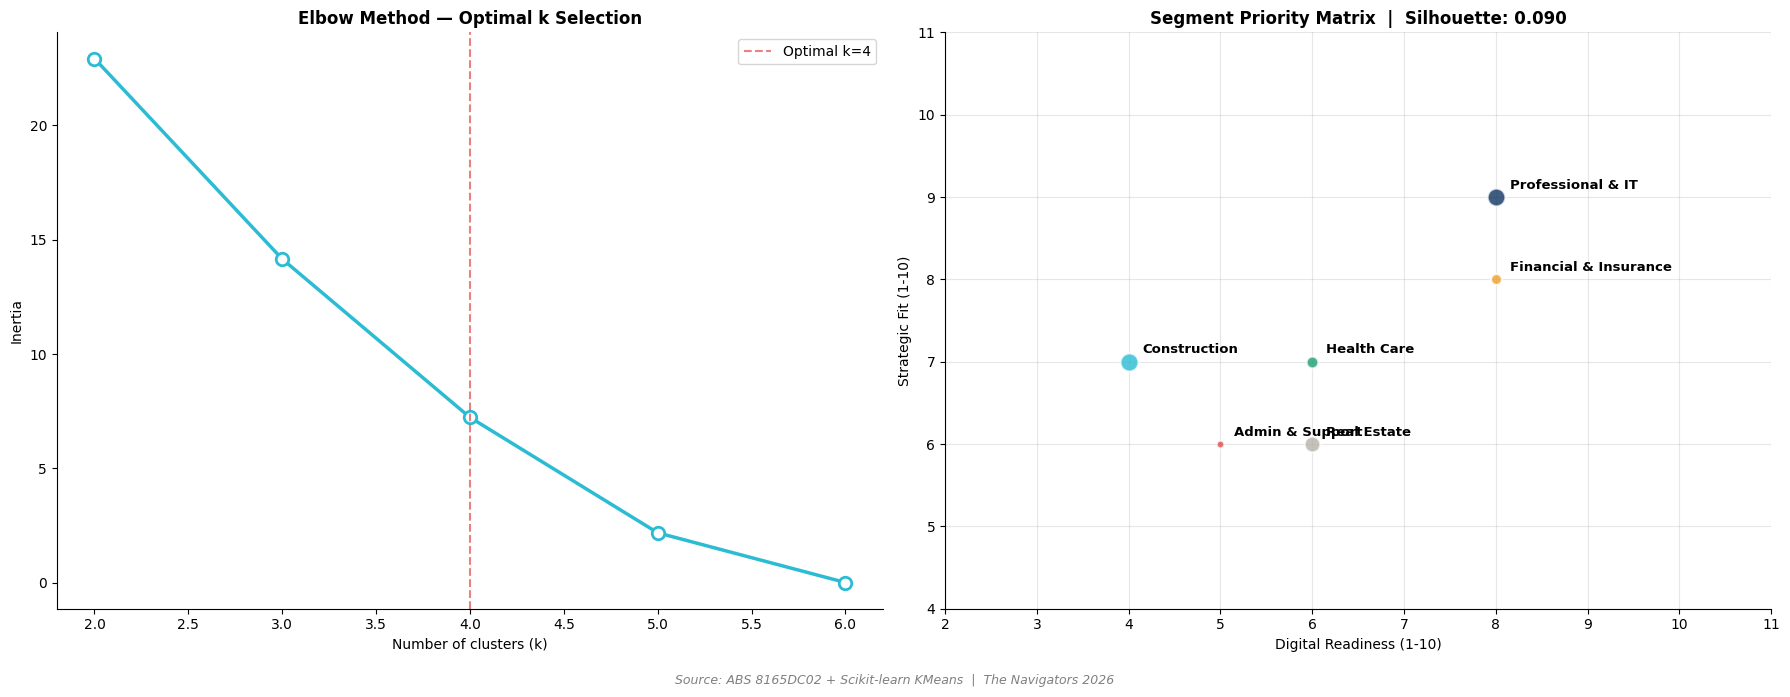

✅ Chart 6 saved


In [56]:
# ══════════════════════════════════════════════════════
# CELL 15 — Chart 6: K-Means Clustering
# ══════════════════════════════════════════════════════

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

segment_matrix = pd.DataFrame({
    "Segment":         ["Professional & IT","Financial & Insurance",
                        "Health Care","Construction","Real Estate","Admin & Support"],
    "WA_Businesses":   [29793, 10972, 12960, 30639, 23029, 5500],
    "Growth_Rate":     [2.5,   3.7,   6.6,   2.2,   3.1,   2.6],
    "Digital_Ready":   [8,     8,     6,     4,     6,     5],
    "Strategic_Fit":   [9,     8,     7,     7,     6,     6],
    "Contractor_Use":  [37.2,  54.8,  37.6,  27.9,  37.0,  36.4],
    "No_IT_Support":   [16.0,  2.6,   9.7,   20.3,  10.4,  14.0],
})

X = segment_matrix[["WA_Businesses","Growth_Rate","Digital_Ready",
                     "Strategic_Fit","Contractor_Use","No_IT_Support"]].values
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

inertias = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_sc)
    inertias.append(km.inertia_)

km4 = KMeans(n_clusters=4, random_state=42, n_init=10)
segment_matrix["Cluster"] = km4.fit_predict(X_sc)
sil = silhouette_score(X_sc, km4.labels_)

print(f"  Silhouette score: {sil:.3f}")
print(segment_matrix[["Segment","Cluster"]].to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

ax1.plot(range(2,7), inertias, "o-", color="#2BBCD4", linewidth=2.5,
         markersize=9, markerfacecolor="white", markeredgewidth=2)
ax1.axvline(4, color="#E24B4A", linestyle="--", alpha=0.7, label="Optimal k=4")
ax1.set_xlabel("Number of clusters (k)"); ax1.set_ylabel("Inertia")
ax1.set_title("Elbow Method — Optimal k Selection", fontsize=12, fontweight="bold")
ax1.legend(); ax1.spines["top"].set_visible(False); ax1.spines["right"].set_visible(False)

seg_colors = ["#0F3460","#EF9F27","#1D9E75","#2BBCD4","#B4B2A9","#E24B4A"]
for i, row in segment_matrix.iterrows():
    s = row["WA_Businesses"] / 180
    ax2.scatter(row["Digital_Ready"], row["Strategic_Fit"],
                s=s, c=seg_colors[i], alpha=0.8, edgecolors="white", linewidth=1.5, zorder=5)
    ax2.annotate(row["Segment"], (row["Digital_Ready"], row["Strategic_Fit"]),
                 textcoords="offset points", xytext=(10,6), fontsize=9.5, fontweight="bold")
ax2.set_xlabel("Digital Readiness (1-10)"); ax2.set_ylabel("Strategic Fit (1-10)")
ax2.set_title(f"Segment Priority Matrix  |  Silhouette: {sil:.3f}",
              fontsize=12, fontweight="bold")
ax2.set_xlim(2, 11); ax2.set_ylim(4, 11); ax2.grid(True, alpha=0.3)
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)

plt.suptitle("Source: ABS 8165DC02 + Scikit-learn KMeans  |  The Navigators 2026",
             y=-0.01, fontsize=9, color="grey", style="italic")
plt.tight_layout()
plt.savefig("chart6_kmeans.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 6 saved")

LEAD SCORING MODEL — 5 TEST LEADS

  Professional Services | 8 staff | 2 days | Missing leads
    Score:    0.96  |  HOT — Follow up today
    Package:  CRM Setup from $2,000

  Financial Services | 5 staff | 1 days | No CRM at all
    Score:    0.96  |  HOT — Follow up today
    Package:  CRM Setup from $2,000

  Health & Wellness | 3 staff | 5 days | No follow-up system
    Score:    0.82  |  HOT — Follow up today
    Package:  CRM Setup from $2,000

  Construction & Trades | 12 staff | 10 days | Manual admin
    Score:    0.69  |  WARM — Follow up this week
    Package:  Growth System from $2,000+

  Other | 2 staff | 20 days | Poor pipeline visibility
    Score:    0.52  |  NURTURE — Email sequence
    Package:  Deep Dive Audit — $600


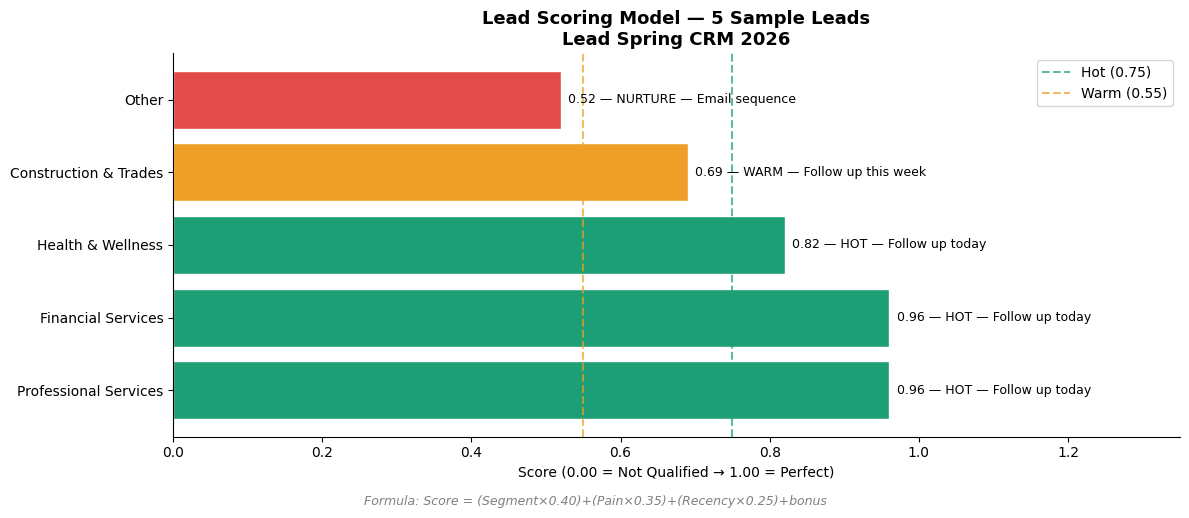

✅ Chart 7 saved


In [57]:
# ══════════════════════════════════════════════════════
# CELL 16 — Lead Scoring Model
# ══════════════════════════════════════════════════════

def score_lead(segment, employees, days, pain, tools="None"):
    seg_scores  = {"Professional Services":0.90,"Financial Services":0.85,
                   "Health & Wellness":0.80,"Construction & Trades":0.70,"Other":0.40}
    pain_scores = {"Missing leads":0.95,"No follow-up system":0.95,
                   "No CRM at all":0.90,"Manual admin":0.90,"Poor pipeline visibility":0.75}
    recency = 1.0 if days<=1 else 0.85 if days<=3 else 0.65 if days<=7 else 0.40 if days<=14 else 0.20
    bonus   = 0.05 if tools=="None" else 0.0
    score   = round(min(max(seg_scores.get(segment,0.40)*0.40
                            + pain_scores.get(pain,0.50)*0.35
                            + recency*0.25 + bonus, 0), 1), 2)
    priority = ("HOT — Follow up today"   if score>=0.75 else
                "WARM — Follow up this week" if score>=0.55 else
                "NURTURE — Email sequence"   if score>=0.35 else "NOT QUALIFIED")
    package  = ("Deep Dive Audit — $600"  if employees<=2 else
                "CRM Setup from $2,000"   if employees<=10 else
                "Growth System from $2,000+")
    return {"Score":score,"Priority":priority,"Package":package}

test_leads = [
    ("Professional Services",  8,  2, "Missing leads",          "None"),
    ("Financial Services",     5,  1, "No CRM at all",          "None"),
    ("Health & Wellness",      3,  5, "No follow-up system",    "Spreadsheet"),
    ("Construction & Trades", 12, 10, "Manual admin",           "Email"),
    ("Other",                  2, 20, "Poor pipeline visibility","None"),
]

print("=" * 60)
print("LEAD SCORING MODEL — 5 TEST LEADS")
print("=" * 60)
results = []
for seg, emp, days, pain, tools in test_leads:
    r = score_lead(seg, emp, days, pain, tools)
    results.append({"Segment":seg,"Employees":emp,"Days":days,
                    "Pain":pain,"Score":r["Score"],"Priority":r["Priority"],"Package":r["Package"]})
    print(f"\n  {seg} | {emp} staff | {days} days | {pain}")
    print(f"    Score:    {r['Score']:.2f}  |  {r['Priority']}")
    print(f"    Package:  {r['Package']}")

df_scores = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(12, 5))
bar_cols = ["#1D9E75" if s>=0.75 else "#EF9F27" if s>=0.55 else "#E24B4A"
            for s in df_scores["Score"]]
ax.barh(df_scores["Segment"], df_scores["Score"], color=bar_cols, edgecolor="white")
ax.axvline(0.75, color="#1D9E75", linestyle="--", alpha=0.7, label="Hot (0.75)")
ax.axvline(0.55, color="#EF9F27", linestyle="--", alpha=0.7, label="Warm (0.55)")
for i, (val, pri) in enumerate(zip(df_scores["Score"], df_scores["Priority"])):
    ax.text(val+0.01, i, f"{val:.2f} — {pri}", va="center", fontsize=9)
ax.set_xlim(0, 1.35)
ax.set_title("Lead Scoring Model — 5 Sample Leads\nLead Spring CRM 2026",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Score (0.00 = Not Qualified → 1.00 = Perfect)")
ax.legend()
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.figtext(0.5,-0.02,
            "Formula: Score = (Segment×0.40)+(Pain×0.35)+(Recency×0.25)+bonus",
            ha="center",fontsize=9,color="grey",style="italic")
plt.tight_layout()
plt.savefig("chart7_lead_scoring.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 7 saved")


In [ ]:
# ══════════════════════════════════════════════════════
# CELL 17 — Export to Excel and download all
# ══════════════════════════════════════════════════════

with pd.ExcelWriter("ABS_Cleaned_All_Data.xlsx", engine="openpyxl") as writer:
    df_t1.to_excel(writer, sheet_name="Industry Data (T1)",       index=False)
    df_t4.to_excel(writer, sheet_name="State Data (T4)",          index=False)
    df_t2.to_excel(writer, sheet_name="Survival Industry (T2)",   index=False)
    df_t5.to_excel(writer, sheet_name="Survival State (T5)",      index=False)
    df_wa.to_excel(writer, sheet_name="WA Classes (DC02)",        index=False)
    df_it.to_excel(writer, sheet_name="IT Use by Industry",       index=False)
    df_scores.to_excel(writer, sheet_name="Lead Scoring Test",    index=False)
    segment_matrix.to_excel(writer, sheet_name="KMeans Data",     index=False)

print("✅ Exported: ABS_Cleaned_All_Data.xlsx  (8 sheets)")

import os
from google.colab import files

outputs = ["ABS_Cleaned_All_Data.xlsx",
           "chart1_wa_growth.png","chart2_industry_growth.png",
           "chart3_survival_rates.png","chart4_wa_segments.png",
           "chart5_it_contractor_use.png","chart6_kmeans.png",
           "chart7_lead_scoring.png"]

print("\nDownloading all outputs...")
for f in outputs:
    if os.path.exists(f):
        files.download(f); print(f"  ✅ {f}")
    else:
        print(f"  ⚠️  Not found: {f}")

print("\n✅ All done! Insert charts into report Appendix E.")